# AnnData Distribution Overview (Pre-Model)

This notebook helps inspect the raw/pre-model expression distribution in `adata` before training SCVI models.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
from scipy import sparse

# Ensure project root imports work when notebook is run from notebooks/
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from config import ADATA_PATH

plt.style.use("default")
np.random.seed(42)

/home/mmonshiz/micromamba/envs/scvi_env/lib/python3.8/site-packages/setuptools_scm/_integration/setuptools.py:31: RuntimeWarning: 
ERROR: setuptools==59.5.0 is used in combination with setuptools_scm>=8.x

Your build configuration is incomplete and previously worked by accident!
setuptools_scm requires setuptools>=61

Suggested workaround if applicable:
 - migrating from the deprecated setup_requires mechanism to pep517/518
   and using a pyproject.toml to declare build dependencies
   which are reliably pre-installed before running the build tools

  warnings.warn(


In [2]:
print(f"Loading AnnData from: {ADATA_PATH}")
adata = sc.read_h5ad(os.path.join(ROOT, ADATA_PATH) if not os.path.isabs(ADATA_PATH) else ADATA_PATH)

print(f"Cells: {adata.n_obs:,}")
print(f"Genes: {adata.n_vars:,}")
print(f"X dtype: {adata.X.dtype}")
print(f"X type: {type(adata.X)}")

Loading AnnData from: pountain_data/outputs/lb_adata.h5ad
Cells: 57,627
Genes: 3,070
X dtype: float64
X type: <class 'numpy.ndarray'>


In [3]:
X = adata.X
is_sparse = sparse.issparse(X)

if is_sparse:
    n_entries = X.shape[0] * X.shape[1]
    nnz = X.nnz
    zero_frac = 1.0 - (nnz / n_entries)

    cell_total_counts = np.asarray(X.sum(axis=1)).ravel()
    genes_per_cell = np.asarray((X > 0).sum(axis=1)).ravel()

    gene_total_counts = np.asarray(X.sum(axis=0)).ravel()
    cells_per_gene = np.asarray((X > 0).sum(axis=0)).ravel()

    nonzero_vals = X.data
else:
    n_entries = X.size
    nnz = int(np.count_nonzero(X))
    zero_frac = 1.0 - (nnz / n_entries)

    cell_total_counts = X.sum(axis=1).ravel()
    genes_per_cell = (X > 0).sum(axis=1).ravel()

    gene_total_counts = X.sum(axis=0).ravel()
    cells_per_gene = (X > 0).sum(axis=0).ravel()

    nonzero_vals = X[X > 0]

print("\nSparsity summary")
print(f"Non-zero entries: {nnz:,} / {n_entries:,}")
print(f"Zero fraction: {zero_frac:.4f} ({100*zero_frac:.2f}%)")
print(f"Non-zero fraction: {1-zero_frac:.4f} ({100*(1-zero_frac):.2f}%)")


Sparsity summary
Non-zero entries: 6,723,071 / 176,914,890
Zero fraction: 0.9620 (96.20%)
Non-zero fraction: 0.0380 (3.80%)


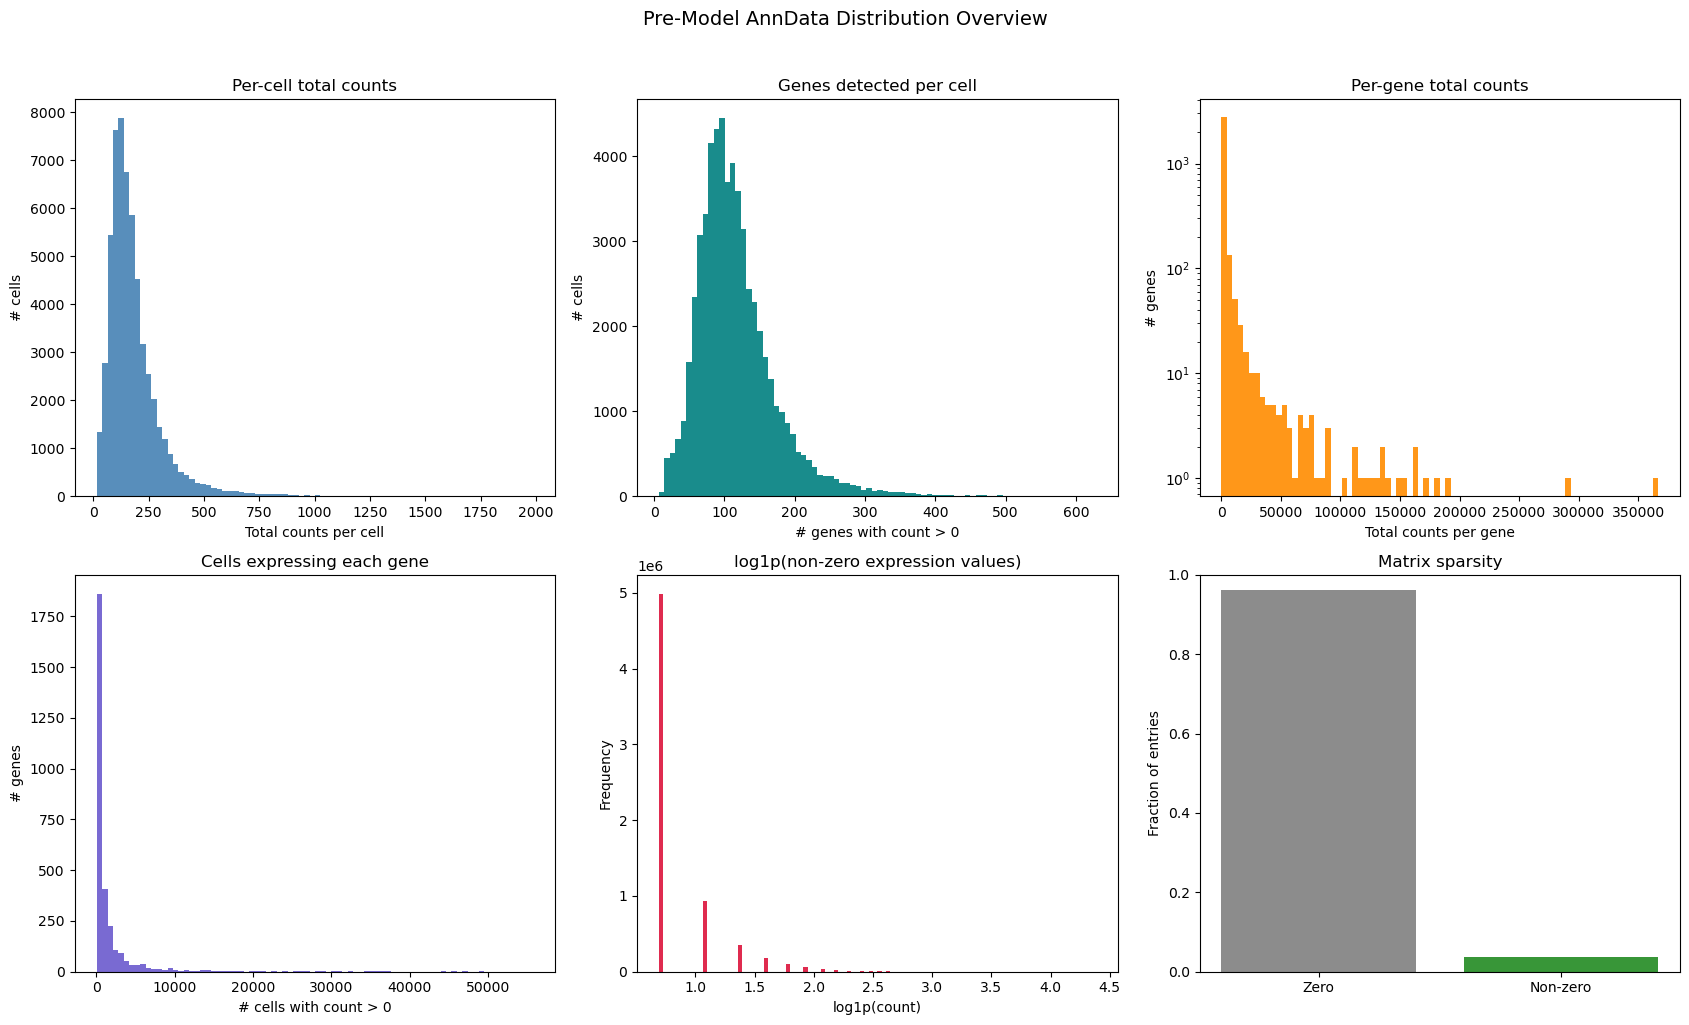

In [5]:
# Subsample nonzero values for faster plotting if needed
# max_nz_plot = 500_000
# if nonzero_vals.size > max_nz_plot:
#     idx = np.random.choice(nonzero_vals.size, size=max_nz_plot, replace=False)
#     nz_plot = nonzero_vals[idx]
# else:
nz_plot = nonzero_vals

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Pre-Model AnnData Distribution Overview", fontsize=14, y=1.02)

axes[0, 0].hist(cell_total_counts, bins=80, color="steelblue", alpha=0.9)
axes[0, 0].set_title("Per-cell total counts")
axes[0, 0].set_xlabel("Total counts per cell")
axes[0, 0].set_ylabel("# cells")

axes[0, 1].hist(genes_per_cell, bins=80, color="teal", alpha=0.9)
axes[0, 1].set_title("Genes detected per cell")
axes[0, 1].set_xlabel("# genes with count > 0")
axes[0, 1].set_ylabel("# cells")

axes[0, 2].hist(gene_total_counts, bins=80, color="darkorange", alpha=0.9)
axes[0, 2].set_title("Per-gene total counts")
axes[0, 2].set_xlabel("Total counts per gene")
axes[0, 2].set_ylabel("# genes")
axes[0, 2].set_yscale("log")

axes[1, 0].hist(cells_per_gene, bins=80, color="slateblue", alpha=0.9)
axes[1, 0].set_title("Cells expressing each gene")
axes[1, 0].set_xlabel("# cells with count > 0")
axes[1, 0].set_ylabel("# genes")

axes[1, 1].hist(np.log1p(nz_plot), bins=100, color="crimson", alpha=0.9)
axes[1, 1].set_title("log1p(non-zero expression values)")
axes[1, 1].set_xlabel("log1p(count)")
axes[1, 1].set_ylabel("Frequency")

axes[1, 2].bar(["Zero", "Non-zero"], [zero_frac, 1-zero_frac], color=["gray", "forestgreen"], alpha=0.9)
axes[1, 2].set_title("Matrix sparsity")
axes[1, 2].set_ylabel("Fraction of entries")
axes[1, 2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [6]:
summary = {
    "cells": int(adata.n_obs),
    "genes": int(adata.n_vars),
    "zero_fraction": float(zero_frac),
    "median_cell_total_counts": float(np.median(cell_total_counts)),
    "median_genes_per_cell": float(np.median(genes_per_cell)),
    "median_gene_total_counts": float(np.median(gene_total_counts)),
    "median_cells_per_gene": float(np.median(cells_per_gene)),
}

print("Quick summary statistics:")
for k, v in summary.items():
    if isinstance(v, float):
        print(f"- {k}: {v:.4f}")
    else:
        print(f"- {k}: {v:,}")

Quick summary statistics:
- cells: 57,627
- genes: 3,070
- zero_fraction: 0.9620
- median_cell_total_counts: 151.0000
- median_genes_per_cell: 106.0000
- median_gene_total_counts: 461.5000
- median_cells_per_gene: 457.5000
